# Data Preparation and EDA

Notebook ini mengubah dataset raw Fragrantica menjadi schema cleaned-like yang stabil untuk training, lalu menyimpan hasil prepared ke folder data notebook.


In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from src.config import INTERIM_DIR, PROCESSED_DIR, dataset_path
from src.preprocessing import (
    CANONICAL_EXPORT_COLUMNS,
    build_clean_export_frame,
    load_dataset,
    prepare_perfume_dataframe,
    save_dataframe,
    validate_columns,
)

sns.set_theme(style='whitegrid')


In [2]:
raw_df = load_dataset(dataset_path())
validate_columns(raw_df)
prepared_df = prepare_perfume_dataframe(raw_df)
clean_export_df = build_clean_export_frame(raw_df)

print('Dataset path:', dataset_path())
print('Raw shape:', raw_df.shape)
print('Prepared shape:', prepared_df.shape)
print('Clean-export shape:', clean_export_df.shape)
display(clean_export_df.head(5))


Dataset path: C:\porto\NemuParfang\ml_training_notebooks\data\raw\fra_perfumes.csv
Raw shape: (70103, 8)
Prepared shape: (70103, 29)
Clean-export shape: (70103, 18)


,url,perfume_name,brand,country,gender,rating,review_count,year,notes_top,notes_middle,notes_base,perfumer1,perfumer2,mainaccord1,mainaccord2,mainaccord3,mainaccord4,mainaccord5
0,https://www.fragrantica.com/perfume/Afnan/9am-...,9am,Afnan,NaN,women,3.73,174.0,NaN,"lemon, mandarin orange, cardamom, pink pepper","lavender, green apple, orange blossom, rose","musk, moss, cedar, patchouli",NaN,NaN,citrus,musky,woody,aromatic,warm spicy
1,https://www.fragrantica.com/perfume/Afnan/9am-...,9am Dive,Afnan,NaN,unisex,4.29,842.0,2022.0,"lemon, mint, black currant, pink pepper","apple, incense, cedar","ginger, sandalwood, patchouli, jasmine",NaN,NaN,fruity,woody,green,warm spicy,aromatic
2,https://www.fragrantica.com/perfume/Afnan/9am-...,9am pour Femme,Afnan,NaN,women,4.00,68.0,2022.0,"mandarin orange, grapefruit, bergamot","raspberry, black currant","musk, amber, orange",NaN,NaN,fruity,musky,amber,citrus,powdery
3,https://www.fragrantica.com/perfume/Afnan/9pm-...,9pm,Afnan,NaN,men,4.50,6865.0,2020.0,"apple, cinnamon, wild lavender, bergamot","orange blossom, lily-of-the-valley","vanilla, tonka bean, amber, patchouli",NaN,NaN,vanilla,amber,warm spicy,cinnamon,sweet
4,https://www.fragrantica.com/perfume/Afnan/9pm-...,9pm pour Femme,Afnan,NaN,women,3.49,63.0,2022.0,"raspberry, violet, apple, orange","rose, iris, peony, jasmine","cypress, pine, cedar, amber",NaN,NaN,woody,aromatic,rose,fruity,powdery


In [3]:
coverage = pd.DataFrame({
    'missing_count': clean_export_df.isna().sum(),
    'missing_ratio': clean_export_df.isna().mean().round(4),
}).sort_values(['missing_ratio', 'missing_count'], ascending=False)
display(coverage)
display(clean_export_df['gender'].value_counts(dropna=False).to_frame('count'))
display(clean_export_df['country'].value_counts(dropna=False).head(20).to_frame('count'))
display(clean_export_df['brand'].value_counts(dropna=False).head(20).to_frame('count'))


,missing_count,missing_ratio
perfumer2,67963,0.9695
country,47306,0.6748
perfumer1,42773,0.6101
notes_top,28727,0.4098
notes_middle,28058,0.4002
notes_base,27578,0.3934
year,14773,0.2107
mainaccord5,9085,0.1296
rating,6181,0.0882
review_count,6181,0.0882


,count
gender,
unisex,29708
women,28102
men,12290
NaN,3


,count
country,
NaN,47306
France,9192
United States,5246
Brazil,2017
United Arab Emirates,1697
Spain,946
United Kingdom,823
Italy,634
Saudi Arabia,604


,count
brand,
The Dua Brand,1638
Avon,1284
Zara,946
Victoria S Secret,764
Bath & Body Works,623
Jequiti,621
O Boticario,551
Guerlain,526
Natura,466


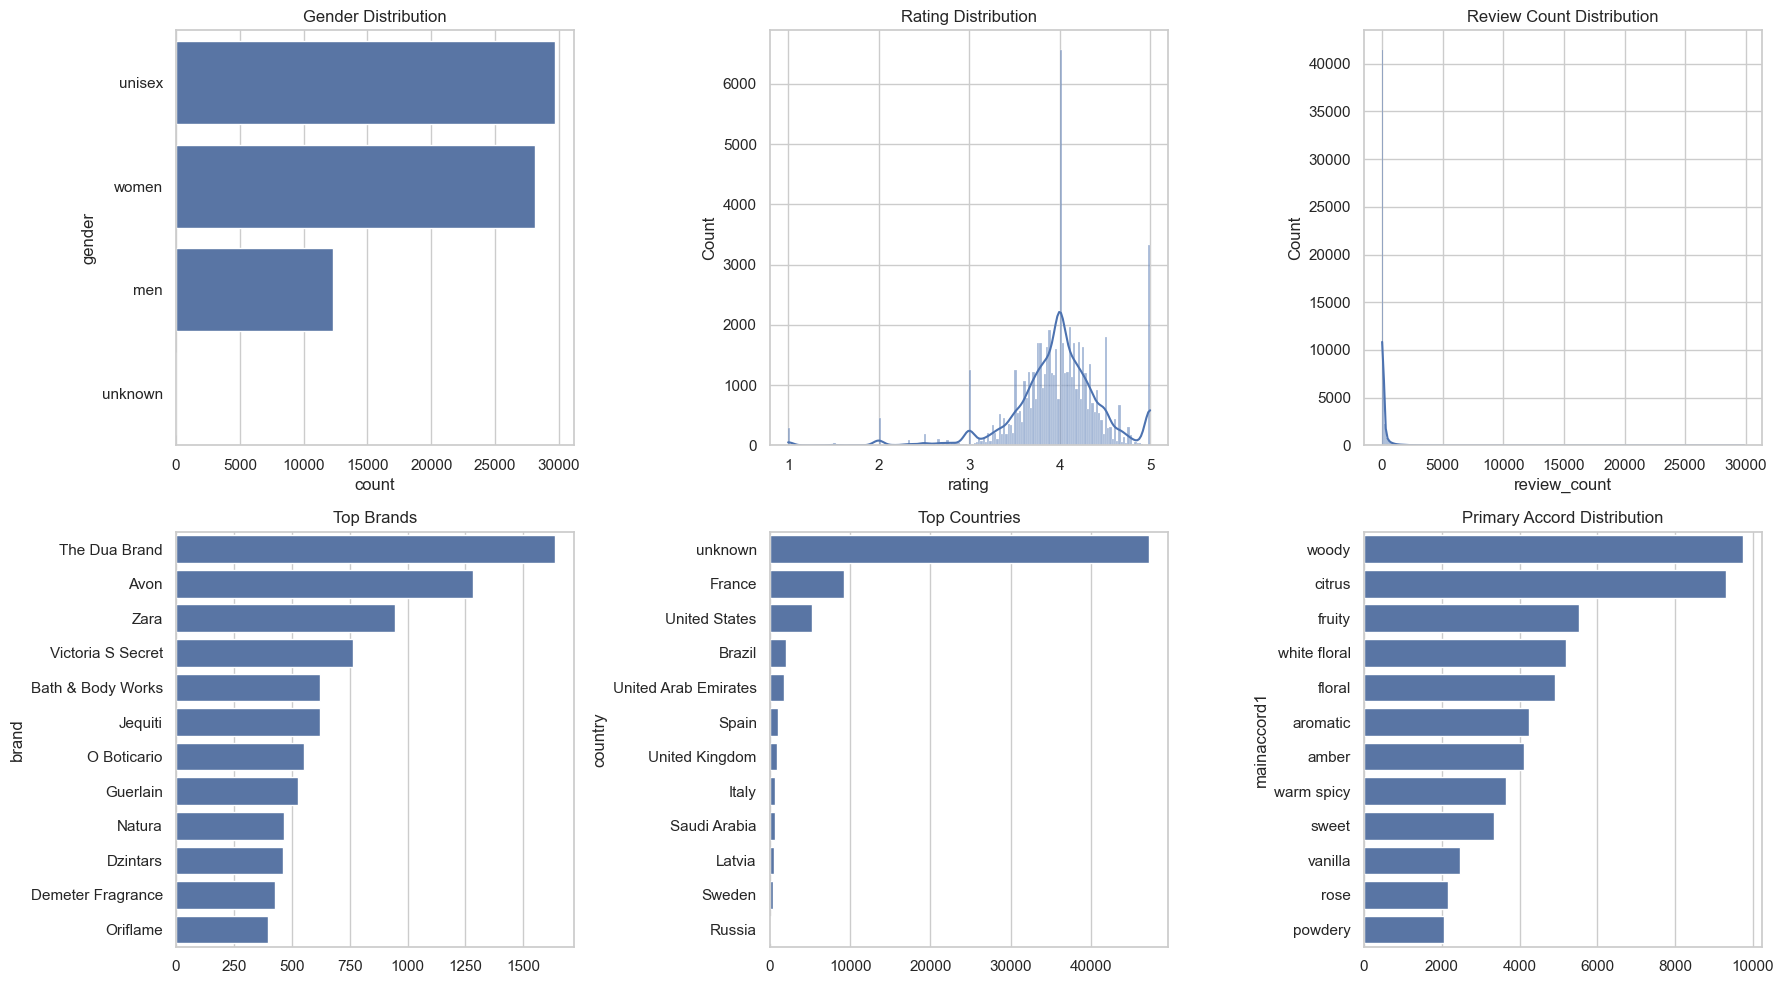

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

gender_plot = clean_export_df['gender'].fillna('unknown').astype(str)
sns.countplot(y=gender_plot, order=gender_plot.value_counts().index, ax=axes[0, 0])
axes[0, 0].set_title('Gender Distribution')

sns.histplot(clean_export_df['rating'].dropna(), kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Rating Distribution')

sns.histplot(clean_export_df['review_count'].dropna(), kde=True, ax=axes[0, 2])
axes[0, 2].set_title('Review Count Distribution')

top_brands = clean_export_df['brand'].fillna('unknown').astype(str).value_counts().head(12)
sns.barplot(x=top_brands.values, y=top_brands.index, ax=axes[1, 0])
axes[1, 0].set_title('Top Brands')

top_countries = clean_export_df['country'].fillna('unknown').astype(str).value_counts().head(12)
sns.barplot(x=top_countries.values, y=top_countries.index, ax=axes[1, 1])
axes[1, 1].set_title('Top Countries')

top_accords = prepared_df['mainaccord1'].fillna('unknown').astype(str).value_counts().head(12)
sns.barplot(x=top_accords.values, y=top_accords.index, ax=axes[1, 2])
axes[1, 2].set_title('Primary Accord Distribution')

plt.tight_layout()


In [5]:
prepared_path = save_dataframe(prepared_df, INTERIM_DIR / 'perfume_prepared.csv')
clean_export_path = save_dataframe(clean_export_df, PROCESSED_DIR / 'perfume_cleaned_export.csv')
print('Prepared dataset saved to:', prepared_path)
print('Clean-export dataset saved to:', clean_export_path)
print('Canonical export columns:', CANONICAL_EXPORT_COLUMNS)


Prepared dataset saved to: C:\porto\NemuParfang\ml_training_notebooks\data\interim\perfume_prepared.csv
Clean-export dataset saved to: C:\porto\NemuParfang\ml_training_notebooks\data\processed\perfume_cleaned_export.csv
Canonical export columns: ['url', 'perfume_name', 'brand', 'country', 'gender', 'rating', 'review_count', 'year', 'notes_top', 'notes_middle', 'notes_base', 'perfumer1', 'perfumer2', 'mainaccord1', 'mainaccord2', 'mainaccord3', 'mainaccord4', 'mainaccord5']
